In [ ]:
import pandas as pd
import numpy as np

### 6.1 Identificação dos parâmetros de um sistema massa mola

# Item (c)

Nesse item, usaremos o **RA 188521**, portanto, o último dígito do RA é **1** e iremos analisar o segundo gráfico ("Resposta ao degrau 1"). Para isso, seguiremos os passos abaixo:

## 1. Identificar o Valor Final e o Ganho ($K$)
O valor final do gráfico converge para aproximadamente **0,33**. Como a entrada é um degrau unitário ($u=1$), o ganho estático do sistema é o próprio valor final:
$$K = 0,33$$

## 2. Determinar o Valor de Pico ($M_p$)
O sobressinal máximo ($M_p$) mostra o quanto a resposta ultrapassa o valor final no primeiro pico. Pela inspeção visual do gráfico, vemos que o valor máximo é aproximadamente $0,44$. 

Calculando o $M_p$ relativo:
$$M_p = \frac{0,44 - 0,33}{0,33} \approx 0,33 \text{ (ou 33\%)}$$



## 3. Calcular o Fator de Amortecimento ($\zeta$)
Utilizando a fórmula baseada no sobressinal:
$$\zeta = \frac{|\ln(M_p)|}{\sqrt{\pi^2 + \ln^2(M_p)}}$$
$$\zeta = \frac{|\ln(0,33)|}{\sqrt{\pi^2 + \ln^2(0,33)}} \approx 0,28$$

## 4. Calcular a Frequência Natural ($\omega_n$)
No eixo horizontal do gráfico, o tempo de pico ($t_p$) — instante onde ocorre o valor máximo — é de aproximadamente **3,2 segundos**. 

A frequência natural é calculada por:
$$\omega_n = \frac{\pi}{t_p\sqrt{1-\zeta^2}}$$
$$\omega_n = \frac{\pi}{3,2\sqrt{1-0,28^2}} \approx 1,01 \text{ rad/s}$$

## 5. Função de Transferência
Substituindo os valores na forma canônica de segunda ordem:
$$G(s) = \frac{K \cdot \omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$
$$G(s) = \frac{0,33 \cdot 1,01^2}{s^2 + 2 \cdot 0,28 \cdot 1,01s + 1,01^2}$$

## 6. Parâmetros de Tempo
Podemos validar os tempos de resposta através das aproximações teóricas:

* **Tempo de Subida ($t_r$):**
$$t_r \approx \frac{1,8}{\omega_n} \approx \frac{1,8}{1,01} \approx 1,78 \text{ segundos}$$

* **Tempo de Estabilização ($t_s$ - critério de 2%):**
$$t_s \approx \frac{4}{\zeta\omega_n} \approx \frac{4}{0,28 \cdot 1,01} \approx 14,08 \text{ segundos}$$

## 7. Resumo dos Resultados
* **Ganho ($K$):** 0,33
* **Fator de amortecimento ($\zeta$):** 0,28
* **Frequência natural ($\omega_n$):** 1,01 rad/s
* **Tempo de subida ($t_r$):** 1,78 s
* **Tempo de estabilização ($t_s$):** 14,08 s
* **Tempo de pico ($t_p$):** 3,2 s


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


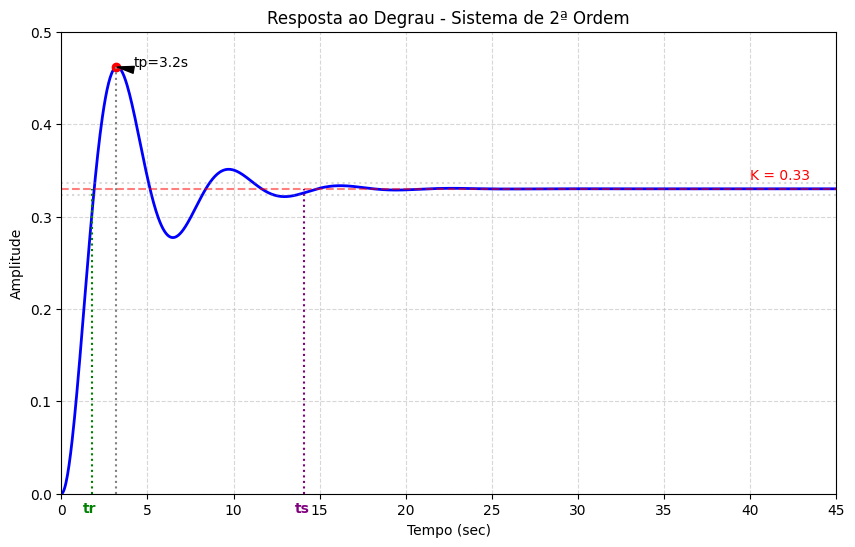

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy import signal
!{sys.executable} -m pip install scipy

# Parâmetros fornecidos
K = 0.33
zeta = 0.28
wn = 1.01
tr = 1.78
ts = 14.08
tp = 3.2

# 1. Definição da Função de Transferência G(s) = (K * wn^2) / (s^2 + 2*zeta*wn*s + wn^2)
num = [K * wn**2]
den = [1, 2 * zeta * wn, wn**2]
sys = signal.TransferFunction(num, den)

# 2. Gerar a resposta ao degrau
t = np.linspace(0, 45, 1000)
t, y = signal.step(sys, T=t)

# 3. Plotagem
plt.figure(figsize=(10, 6))
plt.plot(t, y, 'b', linewidth=2, label='Resposta ao Degrau')

# Marcando o Valor Final (K)
plt.axhline(y=K, color='r', linestyle='--', alpha=0.5)
plt.text(40, K + 0.01, f'K = {K}', color='r')

# Marcando o Tempo de Pico (tp) e Mp
y_max = np.max(y)
plt.plot(tp, y_max, 'ro')
plt.vlines(tp, 0, y_max, colors='gray', linestyles='dotted')
plt.annotate(f'tp={tp}s', xy=(tp, y_max), xytext=(tp+1, y_max),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# Marcando o Tempo de Subida (tr)
# Aproximadamente onde cruza o valor final pela primeira vez
plt.vlines(tr, 0, K, colors='green', linestyles='dotted')
plt.text(tr-0.5, -0.02, 'tr', color='green', fontweight='bold')

# Marcando o Tempo de Estabilização (ts)
plt.vlines(ts, 0, K, colors='purple', linestyles='dotted')
plt.text(ts-0.5, -0.02, 'ts', color='purple', fontweight='bold')

# Faixa de 2% para o ts
plt.axhline(y=K*1.02, color='gray', linestyle=':', alpha=0.3)
plt.axhline(y=K*0.98, color='gray', linestyle=':', alpha=0.3)

# Configurações de eixos e labels
plt.title('Resposta ao Degrau - Sistema de 2ª Ordem')
plt.xlabel('Tempo (sec)')
plt.ylabel('Amplitude')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(0, 0.5) # Ajustado para o ganho de 0.33
plt.xlim(0, 45)

plt.show()